# 01 - EDA : Données Statiques RH

### Objectif
Ce notebook couvre l'analyse exploratoire des **3 fichiers statiques** :
- `general_data` : Données générales des employés
- `employee_survey_data` : Enquête de satisfaction des employés
- `manager_survey_data` : Enquête d'évaluation managériale

### Pourquoi séparer les fichiers d'horaires ?
Les fichiers `in_time` et `out_time` contiennent des séries temporelles (horodatages quotidiens).
Ils nécessitent une phase de feature engineering dédiée (agrégation en moyennes hebdomadaires,
comptage d'heures supplémentaires, etc...) avant de pouvoir être joints au dataset principal.
Mélanger données statiques et temporelles dans un même notebook produirait un code confus et difficile à auditer.

### Plan de ce notebook
- Importation des bibliothèques nécessaires
- Rassemblement des données
- Nettoyage des données
- Réflexion éthique

---
## 0. Importation des bibliothèques nécessaires

In [29]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RAW_DATA_DIR = "../data/raw"
PROCESSED_DATA_DIR = "../data/processed"
print(f"Le répertoire de données est :\n- Raw : {os.path.abspath(RAW_DATA_DIR)}\n- Processed : {os.path.abspath(PROCESSED_DATA_DIR)}")
print()

JOIN_KEY = "EmployeeID"
print(f"La clé de jointure pour les DataFrames est : {JOIN_KEY}")
print()

COL_TO_DELETE = ["EmployeeCount", "Over18", "Gender", "MaritalStatus", "NumCompaniesWorked", "StockOptionLevel", "StandardHours", "DistanceFromHome"]
# ATTENTION PRÉCISER DANS LA PARTIE ÉTHIQUE
# Le retrait du genre car biaisé sur certains critères (congés maternités).
# StatutMarital : Pattern reconnaissable sur un facteur externe de l'entreprise.
# NumCompaniesWorked : Opportunité de travail indépendante de l'individu en lui-même.
# StockOptionLevel : Investissement en action biaisé par la richesse de l'individu.
# StandardHours : Tous les employés ont les mêmes heures de travail, donc pas d'information pertinente.
# DistanceFromHome : Critère impertinent pour évaluer les performances ou les compétences d'un employé.

PLAGES_AGE = [0, 25, 35, 45, 55, 65]
print(f"Les plages d'âge pour la catégorisation sont : {PLAGES_AGE}")

COL_CORR = {
    "EmployeeID":"employee_id",
    "Education":"education",
    "EducationField":"education_field",
    "age_group":"age_group",

    "JobLevel":"job_level",
    "JobRole":"job_role",

    "Department":"department",
    "BusinessTravel":"business_travel",
    
    "MonthlyIncome":"monthly_income",
    "PercentSalaryHike":"percent_salary_hike",
    "TotalWorkingYears":"total_working_years",
    "TrainingTimesLastYear":"training_times_last_year",
    "YearsAtCompany":"years_at_company",
    "YearsSinceLastPromotion":"years_since_last_promotion",
    "YearsWithCurrManager":"years_with_curr_manager",

    "EnvironmentSatisfaction":"environment_satisfaction",
    "JobSatisfaction":"job_satisfaction",
    "WorkLifeBalance":"work_life_balance",
    "JobInvolvement":"job_involvement",
    "PerformanceRating":"performance_rating",

    "Attrition":"has_left",
}

print('Les bibliothèques nécessaires sont importées.')

Le répertoire de données est :
- Raw : c:\Users\Gamas\Documents\RécupGithub\StableDiffusion\IA-groupe-02\src\data\raw
- Processed : c:\Users\Gamas\Documents\RécupGithub\StableDiffusion\IA-groupe-02\src\data\processed

La clé de jointure pour les DataFrames est : EmployeeID

Les plages d'âge pour la catégorisation sont : [0, 25, 35, 45, 55, 65]
Les bibliothèques nécessaires sont importées.


---
## 1. Rassemblement des données

Dans cette première partie, il est questionné de rassembler les données dans un seul dataframe final pour pouvoir ensuite les traiter correctement. Pour ce faire, nous suivrons le plan suivant :
- Chargement des données
- Inspection de la volumétrie, des types et des valeurs manquantes
- Vérification de l'unicité de la clé de jointure
- Merge progressif des dataframes
- Visualisation du dataframe fusionné
- Bilan des valeurs manquantes post-merge

### 1.1. Chargement des données

Les fichiers d'enquête peuvent contenir la chaîne littérale `"NA"` pour signifier une non-réponse.
Par défaut, `pd.read_csv()` reconnaît `"NA"` comme valeur manquante, mais ce comportement est **implicite**.

In [17]:
# On déclare explicitement des valeurs à interpréter comme NaN
NA_VALUES = ["NA"]

df_general = pd.read_csv(os.path.join(RAW_DATA_DIR, 'general_data.csv'), na_values=NA_VALUES).convert_dtypes()
df_survey = pd.read_csv(os.path.join(RAW_DATA_DIR, 'employee_survey_data.csv'), na_values=NA_VALUES).convert_dtypes()
df_manager = pd.read_csv(os.path.join(RAW_DATA_DIR, 'manager_survey_data.csv'), na_values=NA_VALUES).convert_dtypes()

print("Les fichiers CSV ont été chargés dans des DataFrames.")

Les fichiers CSV ont été chargés dans des DataFrames.


### 1.2. Volumétrie, types et valeurs manquantes

Avant toute manipulation, on vérifie pour chaque DataFrame :
- Le nombre de lignes et colonnes (`shape`)
- Les types de chaque colonne (`dtypes`), une colonne numérique en `object` signale un problème
- Le décompte des valeurs manquantes (`isnull().sum()`)

In [18]:
datasets = {
    "General":  df_general,
    "Survey":   df_survey,
    "Manager":  df_manager,
}

for name, df in datasets.items():
    print(f"{'='*50}")
    print(f"{name} : {df.shape[0]} lignes x {df.shape[1]} colonnes")
    print(f"{'='*50}")
    print(df.dtypes)
    print()
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print("Aucune valeur manquante.")
    else:
        print(f"Valeurs manquantes :\n{missing}")
    print()

General : 4410 lignes x 24 colonnes
Age                         Int64
Attrition                  string
BusinessTravel             string
Department                 string
DistanceFromHome            Int64
Education                   Int64
EducationField             string
EmployeeCount               Int64
EmployeeID                  Int64
Gender                     string
JobLevel                    Int64
JobRole                    string
MaritalStatus              string
MonthlyIncome               Int64
NumCompaniesWorked          Int64
Over18                     string
PercentSalaryHike           Int64
StandardHours               Int64
StockOptionLevel            Int64
TotalWorkingYears           Int64
TrainingTimesLastYear       Int64
YearsAtCompany              Int64
YearsSinceLastPromotion     Int64
YearsWithCurrManager        Int64
dtype: object

Valeurs manquantes :
NumCompaniesWorked    19
TotalWorkingYears      9
dtype: int64

Survey : 4410 lignes x 4 colonnes
EmployeeID    

### 1.3. Vérification de l'unicité de la clé de jointure

Avant tout merge, il faut **prouver** que la clé est unique dans chaque DataFrame.
Si elle ne l'est pas, le merge produira un **produit cartésien** silencieux
et gonflera le nombre de lignes sans avertissement.

In [19]:
for name, df in datasets.items():
    n_duplicates = df[JOIN_KEY].duplicated().sum()
    status = "OK" if n_duplicates == 0 else f"ATTENTION : {n_duplicates} doublons !"
    print(f"{name} : clé '{JOIN_KEY}' unique : {status}")

    assert n_duplicates == 0, f"Doublons sur '{JOIN_KEY}' dans {name} — merge impossible en l'état."

General : clé 'EmployeeID' unique : OK
Survey : clé 'EmployeeID' unique : OK
Manager : clé 'EmployeeID' unique : OK


### 1.4. Merge progressif

On fusionne les 3 DataFrames **un par un** en vérifiant la volumétrie après chaque étape.
Un merge `inner` ne conserve que les lignes présentes des deux côtés :
si le nombre de lignes diminue, cela signifie qu'un employé manque dans l'un des fichiers.

In [20]:
n_expected = df_general.shape[0]

# On effectue un premier merge : General + Survey
df_merged = df_general.merge(df_survey, on=JOIN_KEY, how="inner")
print(f"Après merge General + Survey : {df_merged.shape[0]} lignes (attendu : {n_expected})")

# On effectue un second merge: Merged + Manager
df_merged = df_merged.merge(df_manager, on=JOIN_KEY, how="inner")
print(f"Après merge + Manager : {df_merged.shape[0]} lignes (attendu : {n_expected})")

# On effectue un contrôle final
assert df_merged.shape[0] == n_expected, (
    f"Le merge a perdu des lignes ! {n_expected} attendues, {df_merged.shape[0]} obtenues."
)
print(f"\nMerge validé : {df_merged.shape[0]} lignes x {df_merged.shape[1]} colonnes")

Après merge General + Survey : 4410 lignes (attendu : 4410)
Après merge + Manager : 4410 lignes (attendu : 4410)

Merge validé : 4410 lignes x 29 colonnes


### 1.5. Visualisation du Dataframe fusionné

In [21]:
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      4410 non-null   Int64 
 1   Attrition                4410 non-null   string
 2   BusinessTravel           4410 non-null   string
 3   Department               4410 non-null   string
 4   DistanceFromHome         4410 non-null   Int64 
 5   Education                4410 non-null   Int64 
 6   EducationField           4410 non-null   string
 7   EmployeeCount            4410 non-null   Int64 
 8   EmployeeID               4410 non-null   Int64 
 9   Gender                   4410 non-null   string
 10  JobLevel                 4410 non-null   Int64 
 11  JobRole                  4410 non-null   string
 12  MaritalStatus            4410 non-null   string
 13  MonthlyIncome            4410 non-null   Int64 
 14  NumCompaniesWorked       4391 non-null   Int64 
 15

### 1.6. Bilan des valeurs manquantes post-merge

Maintenant que le DataFrame est consolidé, on dresse le bilan complet des NaN
pour savoir quelles colonnes devront être traitées avant la modélisation.

In [22]:
missing_total = df_merged.isnull().sum().sort_values(ascending=False)
missing_total = missing_total[missing_total > 0]

if missing_total.empty:
    print("Aucune valeur manquante dans le DataFrame fusionné.")
else:
    missing_pct = (missing_total / len(df_merged) * 100).round(2)
    summary = pd.DataFrame({"Nombre de NaN": missing_total, "% NaN": missing_pct})
    print(summary)

                         Nombre de NaN  % NaN
WorkLifeBalance                     38   0.86
EnvironmentSatisfaction             25   0.57
JobSatisfaction                     20   0.45
NumCompaniesWorked                  19   0.43
TotalWorkingYears                    9   0.20


---
## 2. Nettoyage des données



### 2.1. Remplissage des valeurs NaN

Au vu du nombre faible de données que nous avons, nous allons remplir les lignes NaN par la valeur médiane pour les colonnes numériques et le mode pour les valeurs catégoriques.

In [23]:
num_cols = df_merged.select_dtypes(include=np.number).columns
cat_cols = df_merged.select_dtypes(include=["object", "string"]).columns
print(f"Nombre de colonnes numériques : {len(num_cols)}")
print(f"Nombre de colonnes catégorielles : {len(cat_cols)}")

# On remplace les NaN des colonnes numériques par la médiane
df_merged[num_cols] = df_merged[num_cols].fillna(df_merged[num_cols].median())
df_merged[cat_cols] = df_merged[cat_cols].fillna(df_merged[cat_cols].mode().iloc[0])

print("Les valeurs manquantes ont été traitées !")

Nombre de colonnes numériques : 21
Nombre de colonnes catégorielles : 8
Les valeurs manquantes ont été traitées !


### 2.2. Suppression des colonnes inutiles

Certaines colonnes ne servent à rien pour l'analyse ultérieure des données, nous les supprimons donc.

In [24]:
# On supprime les colonnes inutiles
df_final = df_merged.drop(columns=COL_TO_DELETE)
print(f"Colonnes supprimées : {COL_TO_DELETE}")
print(f"DataFrame final : {df_final.shape[0]} lignes x {df_final.shape[1]} colonnes")
print()
print(df_final.head())

Colonnes supprimées : ['EmployeeCount', 'Over18', 'Gender', 'MaritalStatus', 'NumCompaniesWorked', 'StockOptionLevel', 'StandardHours', 'DistanceFromHome']
DataFrame final : 4410 lignes x 21 colonnes

   Age Attrition     BusinessTravel              Department  Education  \
0   51        No      Travel_Rarely                   Sales          2   
1   31       Yes  Travel_Frequently  Research & Development          1   
2   32        No  Travel_Frequently  Research & Development          4   
3   38        No         Non-Travel  Research & Development          5   
4   32        No      Travel_Rarely  Research & Development          1   

  EducationField  EmployeeID  JobLevel                    JobRole  \
0  Life Sciences           1         1  Healthcare Representative   
1  Life Sciences           2         1         Research Scientist   
2          Other           3         4            Sales Executive   
3  Life Sciences           4         3            Human Resources   
4        

### 2.3. Catégorisation des âges

Pour éviter d'utiliser directement des informations sensibles, on regroupe les âges dans des groupes d'âges.

In [ ]:
# On définit les labels
labels = [f"{PLAGES_AGE[i]}-{PLAGES_AGE[i+1]}" for i in range(len(PLAGES_AGE)-1)]
labels[0] = f"< {PLAGES_AGE[1]}"
labels[len(labels)-1] = f"> {PLAGES_AGE[len(PLAGES_AGE)-1]}"

# On définit une catégorie d'âge pour chaque employé
df_final["age_group"] = df_final["Age"].apply(lambda x: pd.cut([x], bins=PLAGES_AGE, labels=labels)[0])
df_final = df_final.drop(columns=["Age"])

print("La catégorie d'âge a été ajoutée au DataFrame final.")

La catégorie d'âge a été ajoutée au DataFrame final.
     Attrition     BusinessTravel              Department  Education  \
0           No      Travel_Rarely                   Sales          2   
1          Yes  Travel_Frequently  Research & Development          1   
2           No  Travel_Frequently  Research & Development          4   
3           No         Non-Travel  Research & Development          5   
4           No      Travel_Rarely  Research & Development          1   
...        ...                ...                     ...        ...   
4395        No      Travel_Rarely  Research & Development          3   
4396        No      Travel_Rarely  Research & Development          1   
4397        No  Travel_Frequently  Research & Development          4   
4398        No      Travel_Rarely  Research & Development          4   
4399        No      Travel_Rarely  Research & Development          3   

     EducationField  EmployeeID  JobLevel                    JobRole  \
0     Life

### 2.4. Renommage des colonnes

On renomme les colonnes du dataframe pour une meilleure clarté.

In [30]:
# On renomme les colonnes pour plus de clarté
df_final.rename(columns=COL_CORR, inplace=True)
print("Les colonnes ont été renommées pour plus de clarté.")

Les colonnes ont été renommées pour plus de clarté.


### 2.5. Sauvegarde du CSV

On sauvegarde dans le 

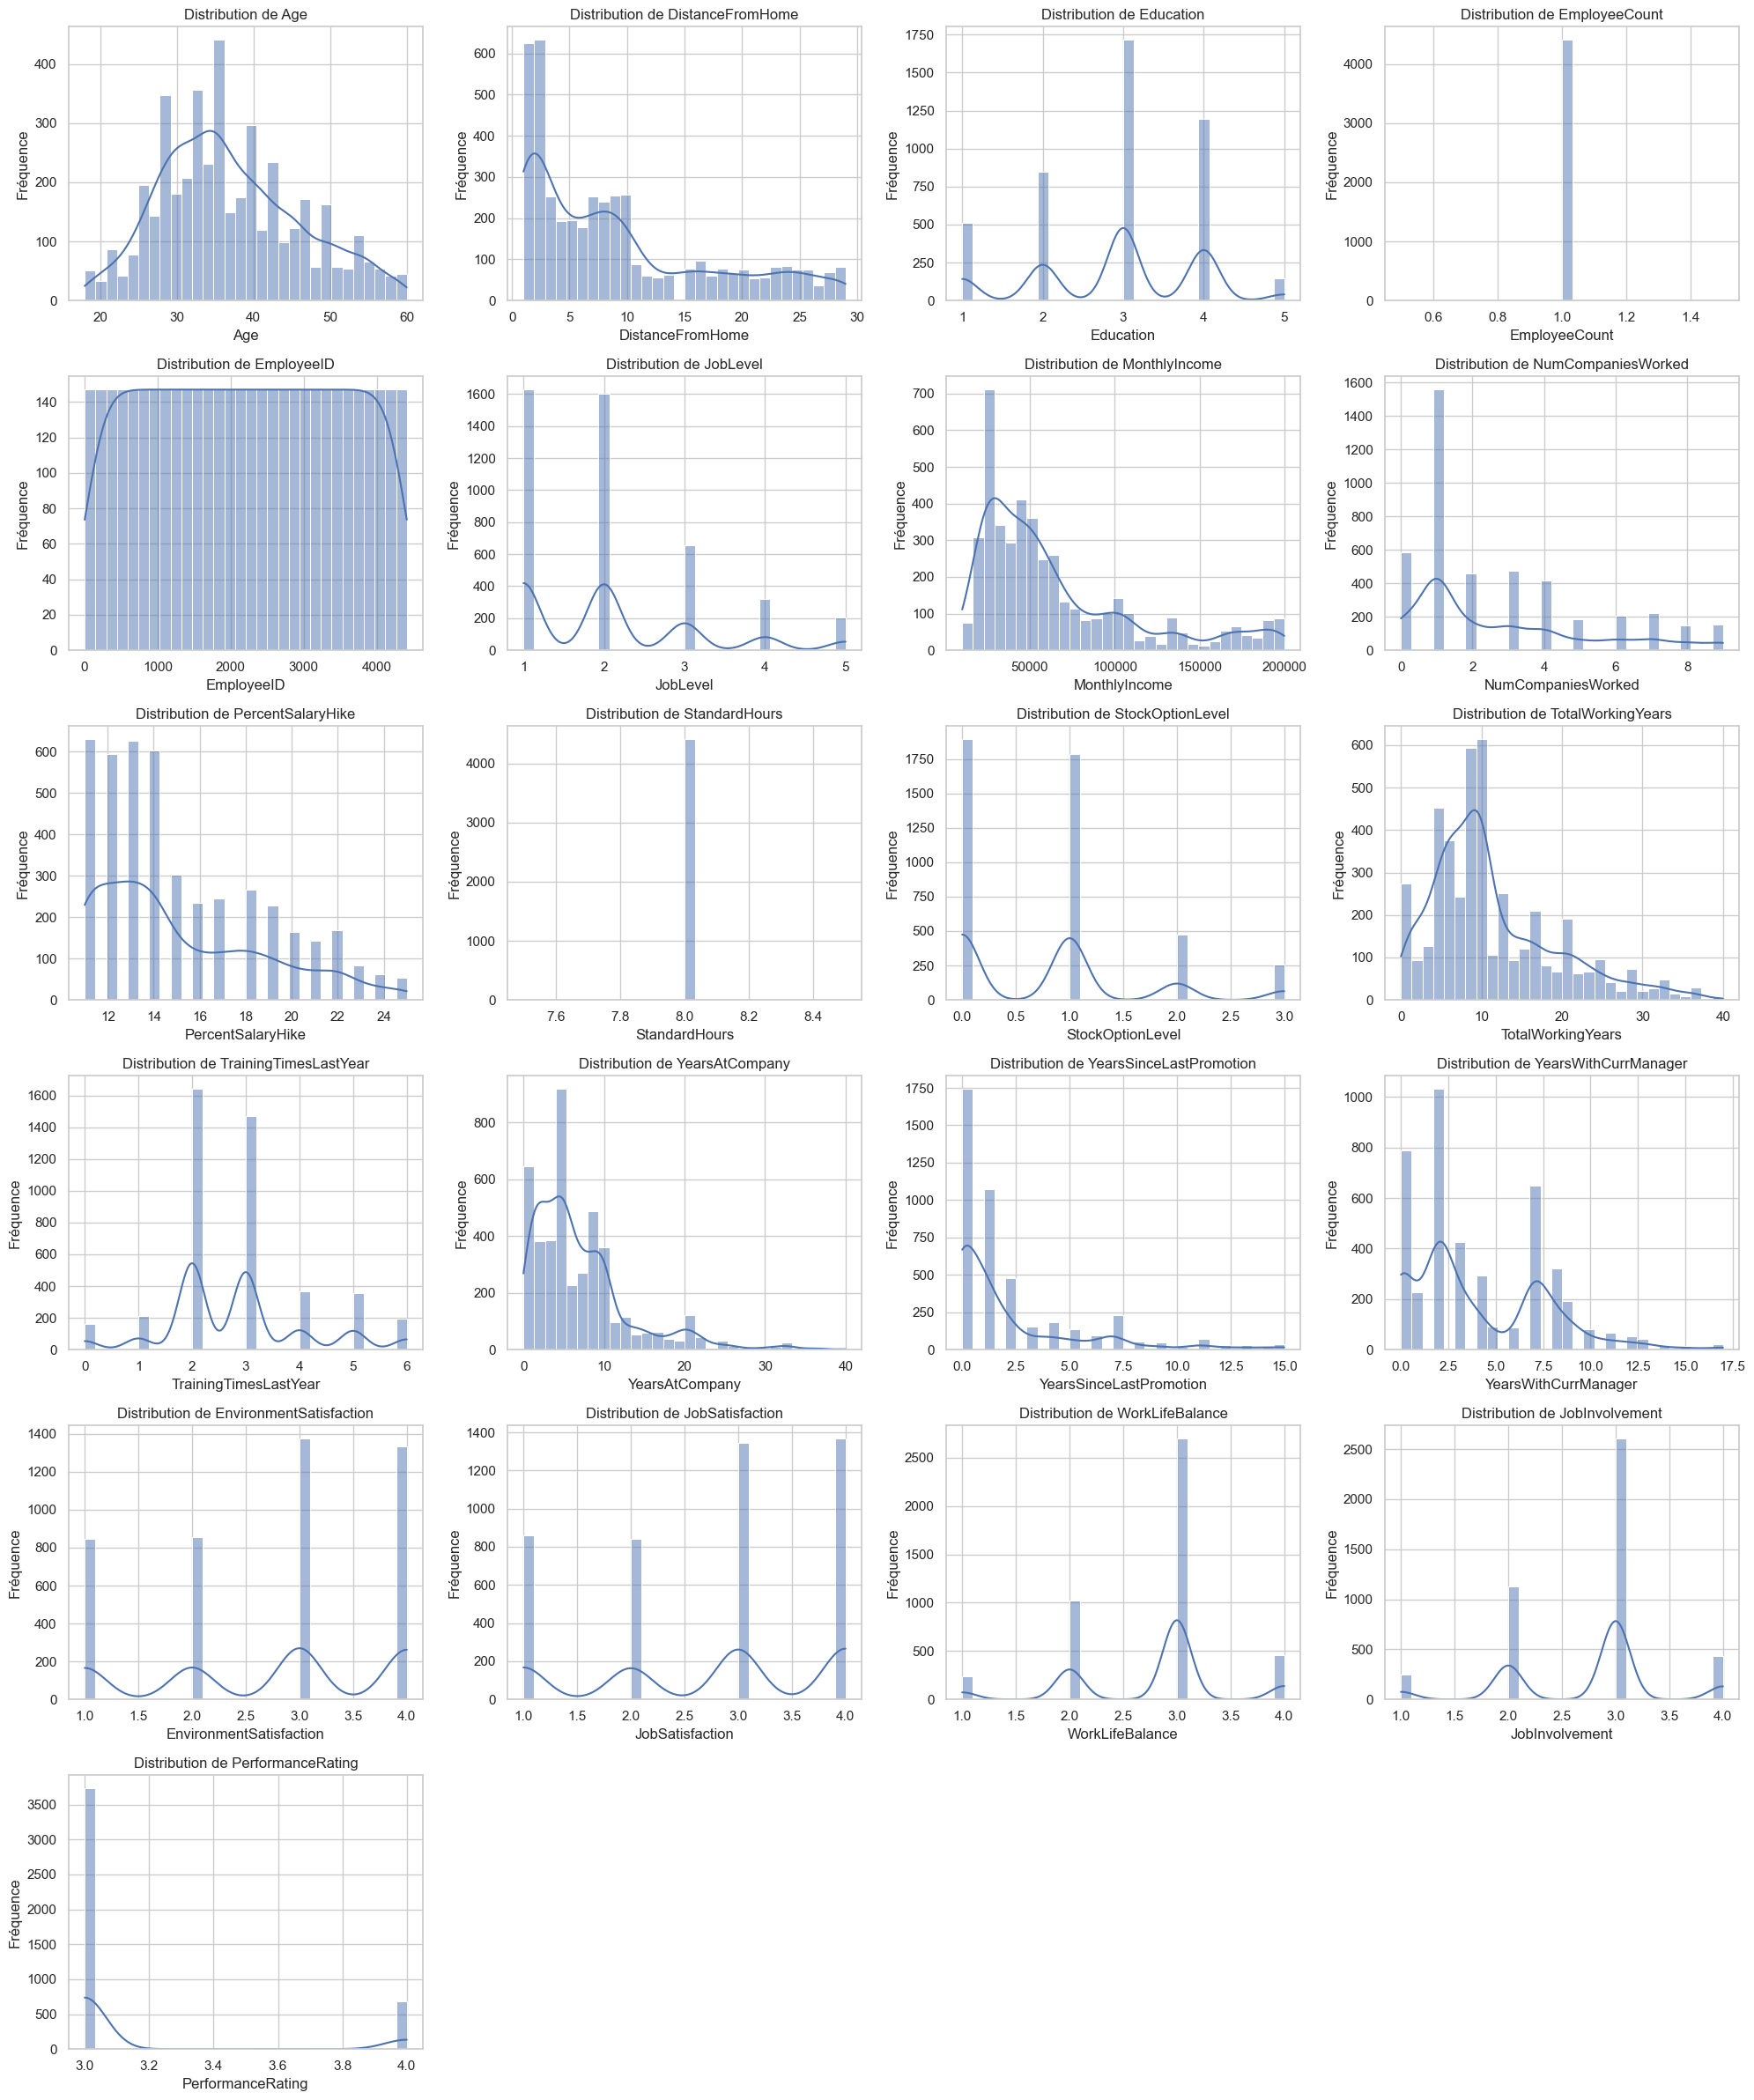

In [69]:
# On affiche un histogramme de chaque colonne numérique
n = len(num_cols)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig = plt.figure(figsize=(5 * ncols, 4 * nrows))
for i, col in enumerate(num_cols):
    ax = fig.add_subplot(nrows, ncols, i + 1)
    sns.histplot(df_merged[col], kde=True, bins=30, ax=ax)
    ax.set_title(f"Distribution de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Fréquence")

plt.tight_layout()
plt.show()

---
## 7. Détection d'outliers sur les variables numériques

### Méthode
1. **`describe()`** pour repérer rapidement les min/max suspects
   (ex: un âge de 0 ou un salaire négatif)
2. **Boxplots** pour visualiser la dispersion et les points au-delà
   des moustaches (1.5 x IQR par défaut dans Seaborn)

### Attention
Un outlier n'est pas forcément une erreur. Un salaire très élevé peut être celui
d'un dirigeant. La décision de traiter ou conserver un outlier est **métier**, pas technique.

In [59]:
# Sélection automatique des colonnes numériques (sans l'identifiant)
num_cols = df_merged.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != KEY]

print(f"{len(num_cols)} colonnes numériques détectées :")
print(num_cols)

NameError: name 'KEY' is not defined

In [ ]:
# Statistiques descriptives — cherchez les min/max incohérents
df_merged[num_cols].describe().round(2)

,Age,DistanceFromHome,Education,EmployeeCount,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
count,4410.00,4410.00,4410.00,4410.0,4410.00,4410.00,4391.00,4410.00,4410.0,4410.00,4401.00,4410.00,4410.00,4410.00,4410.00,4385.00,4390.00,4372.00,4410.00,4410.00
mean,36.92,9.19,2.91,1.0,2.06,65029.31,2.69,15.21,8.0,0.79,11.28,2.80,7.01,2.19,4.12,2.72,2.73,2.76,2.73,3.15
std,9.13,8.11,1.02,0.0,1.11,47068.89,2.50,3.66,0.0,0.85,7.78,1.29,6.13,3.22,3.57,1.09,1.10,0.71,0.71,0.36
min,18.00,1.00,1.00,1.0,1.00,10090.00,0.00,11.00,8.0,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,3.00
25%,30.00,2.00,2.00,1.0,1.00,29110.00,1.00,12.00,8.0,0.00,6.00,2.00,3.00,0.00,2.00,2.00,2.00,2.00,2.00,3.00
50%,36.00,7.00,3.00,1.0,2.00,49190.00,2.00,14.00,8.0,1.00,10.00,3.00,5.00,1.00,3.00,3.00,3.00,3.00,3.00,3.00
75%,43.00,14.00,4.00,1.0,3.00,83800.00,4.00,18.00,8.0,1.00,15.00,3.00,9.00,3.00,7.00,4.00,4.00,3.00,3.00,3.00
max,60.00,29.00,5.00,1.0,5.00,199990.00,9.00,25.00,8.0,3.00,40.00,6.00,40.00,15.00,17.00,4.00,4.00,4.00,4.00,4.00


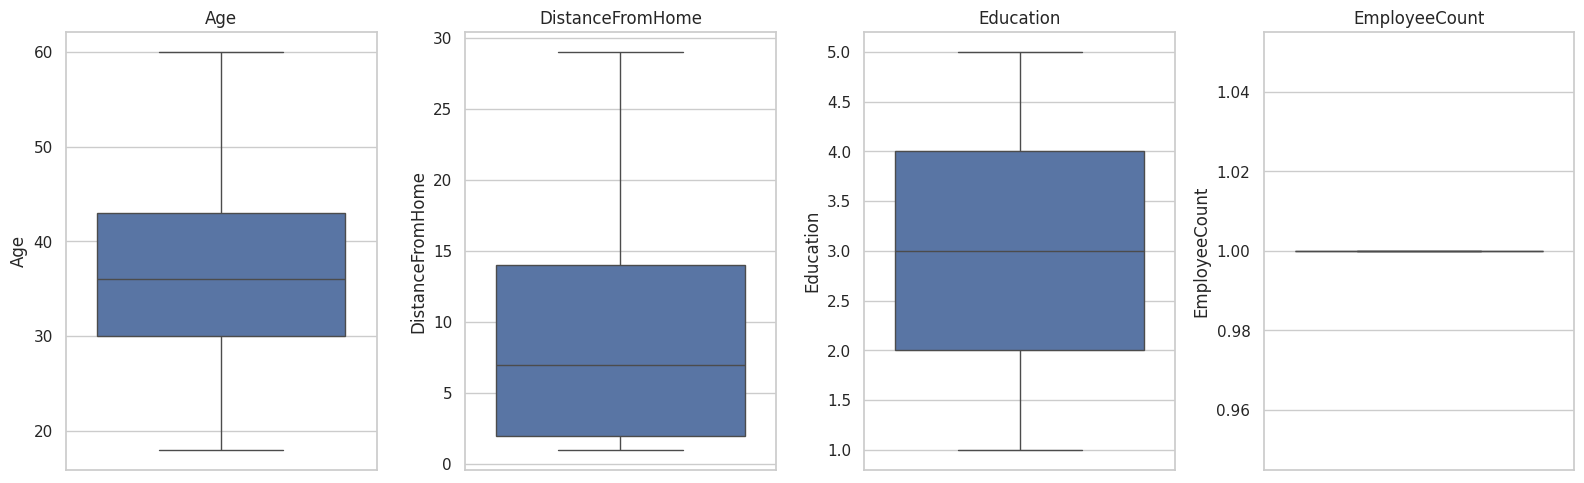

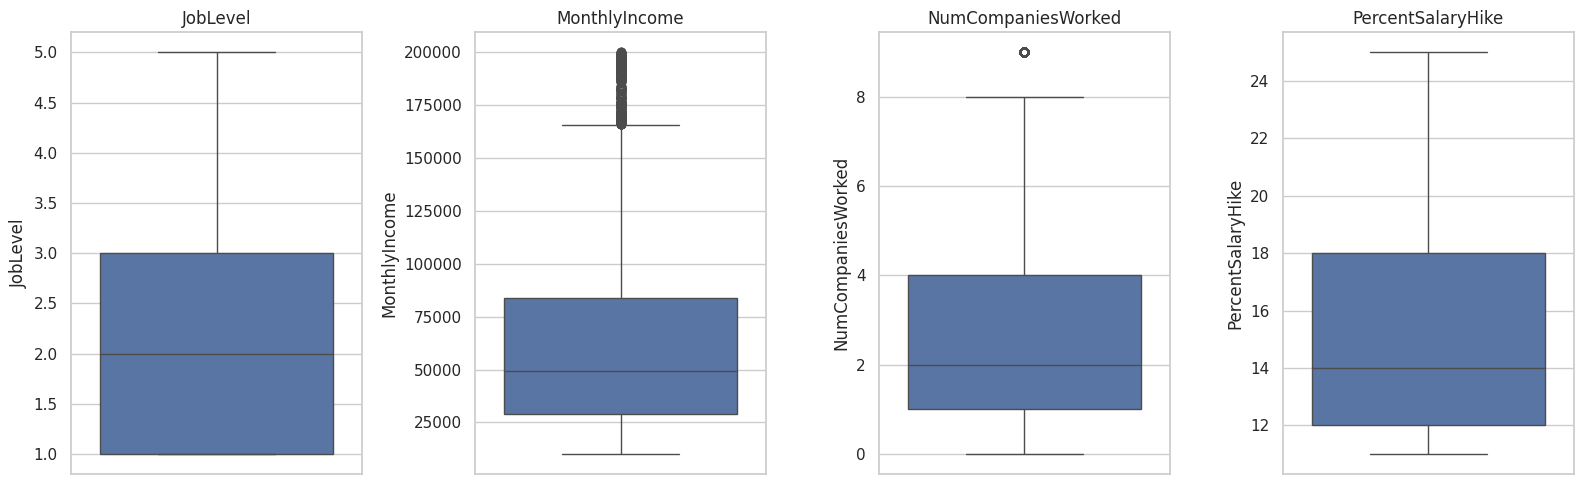

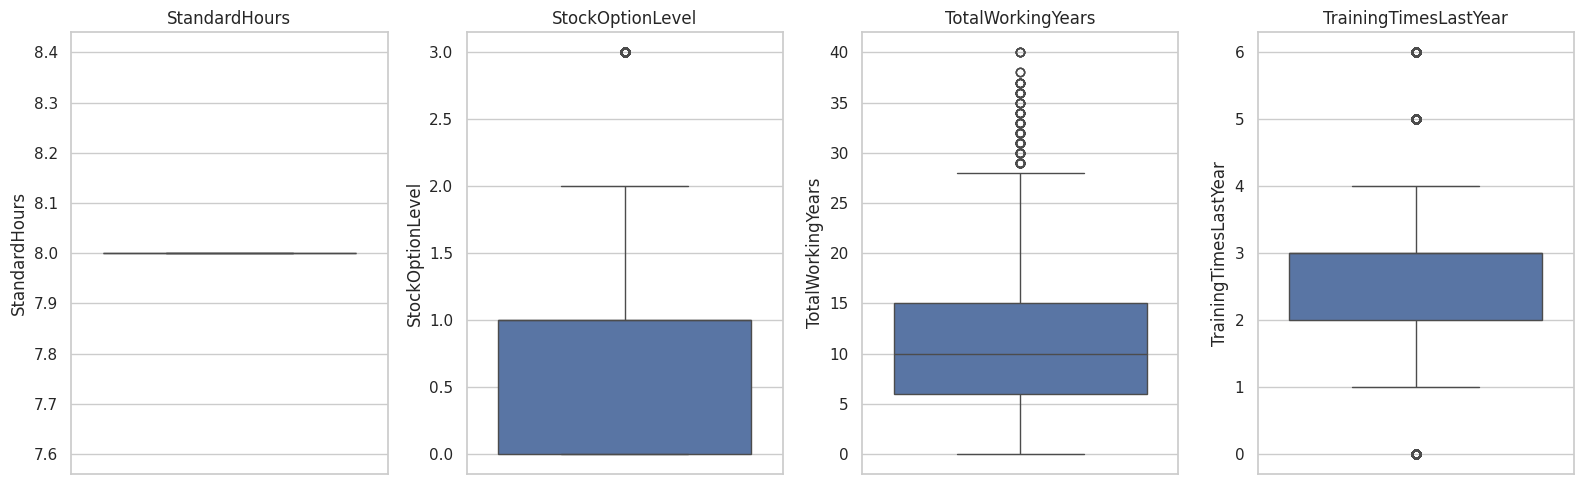

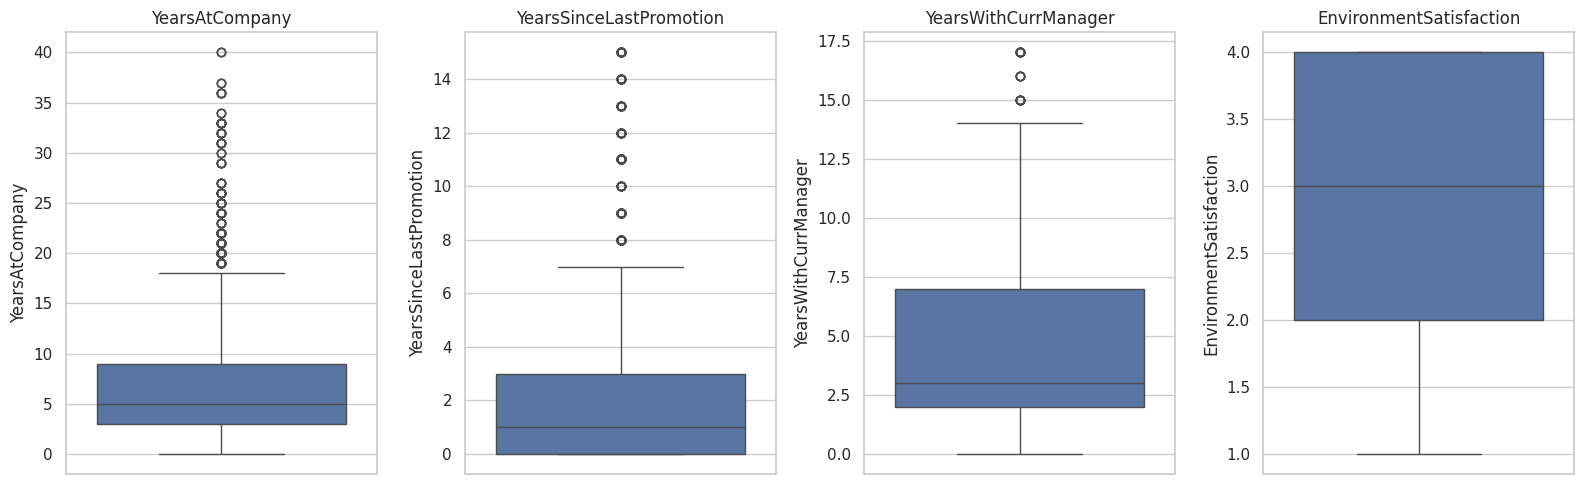

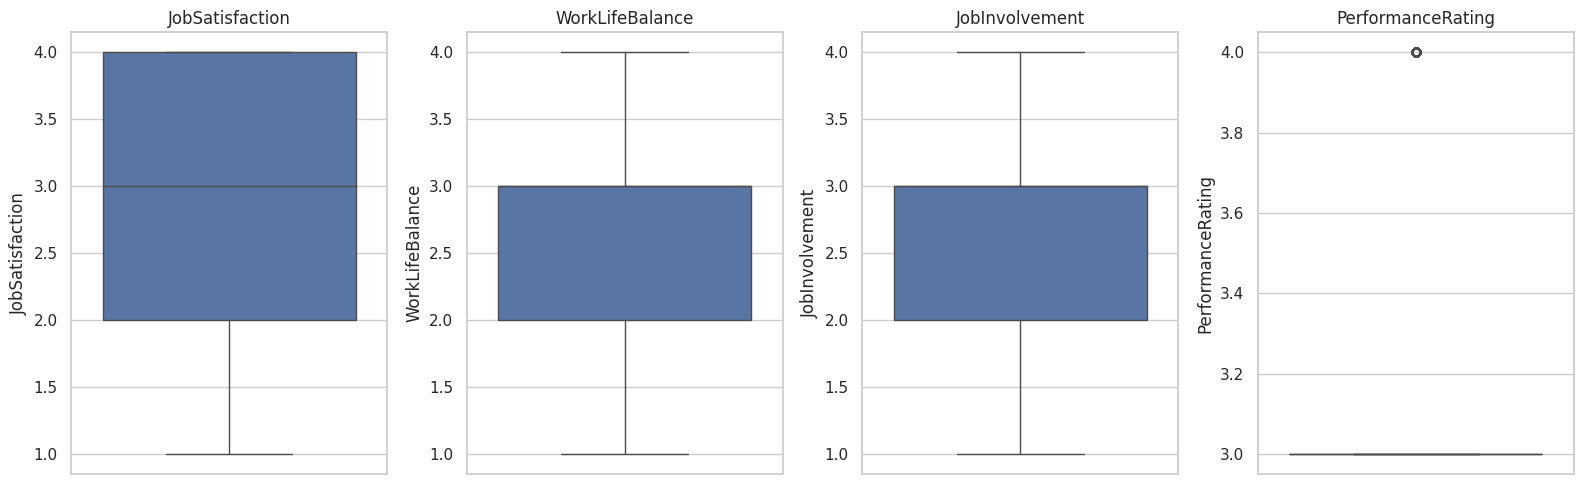

In [ ]:
# Boxplots par groupes de colonnes (pour éviter un graphique illisible)
COLS_PER_FIG = 4

for i in range(0, len(num_cols), COLS_PER_FIG):
    subset = num_cols[i : i + COLS_PER_FIG]
    fig, axes = plt.subplots(1, len(subset), figsize=(4 * len(subset), 5))
    if len(subset) == 1:
        axes = [axes]
    for ax, col in zip(axes, subset):
        sns.boxplot(y=df_merged[col], ax=ax)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

### Observations — Outliers et colonnes suspectes

**Colonnes à variance nulle (std = 0) :**
- `EmployeeCount` : toutes les valeurs = [...] → décision : [garder / supprimer] car [...]
- `StandardHours` : toutes les valeurs = [...] → décision : [garder / supprimer] car [...]
- `Over18` : vérifier avec `df_merged["Over18"].nunique()` → [...]

**Colonnes à très faible variance :**
- `PerformanceRating` : seulement les valeurs [...] et [...] → est-ce un vrai signal ou un biais d'évaluation ? [...]

**Outliers détectés sur les boxplots :**
- `MonthlyIncome` : valeurs extrêmes hautes → erreur ou salaire de dirigeant ? Croisez avec `JobLevel` pour vérifier : [...]
- `YearsAtCompany` / `TotalWorkingYears` : max = 40 → cohérent avec l'âge max de 60 ? [...]
- Autres observations : [...]

**Décisions finales :**
- Colonnes à **supprimer** avant modélisation : [...]
- Outliers à **traiter** : [...]
- Outliers à **conserver** (cas métier légitimes) : [...]

---
## 6. Réflexion Éthique

Nous venons de fusionner des données RH générales (âge, genre, salaire) avec des réponses
issues d'**enquêtes de satisfaction** et d'**évaluations managériales**.

Ces enquêtes ont souvent été remplies par les employés sous une promesse implicite
ou explicite de **confidentialité**.

### Question
Si votre modèle de prédiction d'attrition exploite les scores de satisfaction pour identifier
les employés sur le départ, quel impact cela pourrait-il avoir sur la **confiance des employés**
envers les futures enquêtes internes ?

Quel principe parmi les **7 exigences de l'UE pour une IA de confiance** est directement concerné ?

> *Notez votre réflexion ici avant de poursuivre.*